# Assignment 3
## Note: DON'T RUN THIS UNTIL YOU HAVE MADE SURE YOUR CODE WORKS LOCALLY; THIS NOTEBOOK TAKES **~1 HOUR TO RUN**.

## See https://edstem.org/us/courses/33056/discussion/2523780 For a guide to use Colab GPUs.

Please make a copy of this Colab notebook in your own Google Drive to edit it.

This serves as an Azure alternative in case we have a dreadful case of GPU shortage. Feel free to copy this setup for other assignments.

## 1. Connect with GPU

To run on GPU, please make sure your runtime type is using the GPU accelerator! To do so, click on:

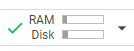

on the upper-right hand corner, then click "Change runtime type" in the bottom-left of the popped-up panel, then select "T4 GPU" as your hardware accelerator. Then click on Connect to run the code on GPU.

## 2. Upload your files

### Option 1: Upload your files to your Google Drive, and mount the drive
You can upload your files to your own Google drive. This is the ''safest'' way to set up the Colab, since your files are stored in your Google Drive instead of the Colab Runtime, which may terminate if you leave it on for too long (~8 hours, or if you put your laptop to sleep mode) and lose your files.

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Option 2: Zip your folder, upload, then unzip
Zip your code folder. Upload the folder of your code to the runtime (drag and drop) so that the structure of Files would look like the following:
- ..
- sample_data
- your_folder.zip

Then run the following code block to unzip the file.

NOTE THAT IF YOU LEAVE YOUR COLAB NOTEBOOK ALONE FOR TOO LONG, THERE IS A RISK THAT YOU WILL LOSE YOUR FILES.

In [10]:
! unzip /content/Assignment3.zip # replace this with the name of your zip file

Archive:  /content/Assignment3.zip
   creating: Assignment3/
  inflating: Assignment3/run.py      
  inflating: Assignment3/vocab.py    
   creating: Assignment3/zh_en_data/
  inflating: Assignment3/zh_en_data/dev.en  
  inflating: Assignment3/zh_en_data/train.zh  
  inflating: Assignment3/zh_en_data/dev.zh  
  inflating: Assignment3/zh_en_data/train.en  
  inflating: Assignment3/zh_en_data/train_debug.zh  
  inflating: Assignment3/zh_en_data/test.en  
  inflating: Assignment3/zh_en_data/train_debug.en  
  inflating: Assignment3/zh_en_data/test.zh  
  inflating: Assignment3/Assignment3_Colab__Setup.ipynb  
 extracting: Assignment3/gpu_requirements.txt  
  inflating: Assignment3/run.bat     
  inflating: Assignment3/tgt.model   
 extracting: Assignment3/__init__.py  
  inflating: Assignment3/src.vocab   
   creating: Assignment3/__pycache__/
  inflating: Assignment3/__pycache__/utils.cpython-38.pyc  
  inflating: Assignment3/__pycache__/vocab.cpython-38.pyc  
  inflating: Assignment3/__

##3. Install Dependencies

Run the following cell to install dependencies for this assignment.

In [11]:
!pip install docopt sentencepiece sacrebleu

## 4. Relocate to your code directory

In [12]:
%cd Assignment3
! ls # verify that you are in the right directory

/content/Assignment3/Assignment3
Assignment3_Colab__Setup.ipynb	outputs			 src.model
Assignment-3.docx		__pycache__		 src.vocab
collect_submission.bat		README.md		 tgt.model
collect_submission.sh		run.bat			 tgt.vocab
gpu_requirements.txt		run.py			 utils.py
__init__.py			runs			 vocab.json
local_env.yml			run.sh			 vocab.py
model_embeddings.py		sanity_check_en_es_data  zh_en_data
nmt_model.py			sanity_check.py


## 5. Run assignment-specific commands

Now you can directly run the commands specified by the assignment files in the following code blocks.

In [13]:
#optional
!pip uninstall -y torch torchvision torchaudio
!pip install torch==2.5.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
#While training the model if get an error related to 'torch.load' run the above lines then retrain model using following line
! sh run.sh train

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 97.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 119.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 86.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 57.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 110.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

### Optional: If you encounter an error related to `torch.load`
_pickle.UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint.

Check the documentation of torch.load to learn more about types accepted by default with weights_only https://pytorch.org/docs/stable/generated/torch.load.html.

run the next cell

For testing

In [14]:
! sh run.sh test

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
2026-04-07 00:20:46.293253: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775521246.314794   46243 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775521246.321621   46243 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775521246.338693   46243 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775521246.338742   46243 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [15]:
# After you have verified that everything works, you can collect your submission
%cd /content/Assignment3/Assignment3
! sh collect_submission.sh

  adding: __init__.py (stored 0%)
  adding: model_embeddings.py (deflated 60%)
  adding: nmt_model.py (deflated 76%)
  adding: run.py (deflated 72%)
  adding: sanity_check.py (deflated 78%)
  adding: utils.py (deflated 62%)
  adding: vocab.py (deflated 69%)
  adding: zh_en_data/ (stored 0%)
  adding: zh_en_data/test.en (deflated 62%)
  adding: zh_en_data/train_debug.zh (deflated 30%)
  adding: zh_en_data/train_debug.en (deflated 62%)
  adding: zh_en_data/train.zh (deflated 52%)
  adding: zh_en_data/train.en (deflated 64%)
  adding: zh_en_data/dev.zh (deflated 50%)
  adding: zh_en_data/test.zh (deflated 50%)
  adding: zh_en_data/dev.en (deflated 62%)
  adding: sanity_check_en_es_data/ (stored 0%)
  adding: sanity_check_en_es_data/dev_sanity_check.es (deflated 48%)
  adding: sanity_check_en_es_data/step_o_t_19.pkl (deflated 52%)
  adding: sanity_check_en_es_data/step_o_t_7.pkl (deflated 52%)
  adding: sanity_check_en_es_data/step_o_t_17.pkl (deflated 52%)
  adding: sanity_check_en_es_dat

## 6. Download your files
If you used Option 2, where your files are not directly in your Google drive, you would need to download the files you have generated in the process. We primarily need your test_outputs.txt file in your outputs/ folder to compute the BLEU score. You can also zip the entire folder and download the whole folder in the following cell block:

In [1]:
#%cd ../../ #change the current working directory
!zip -r downloading.zip /content/Assignment3
from google.colab import files
files.download('downloading.zip')

	zip warning: name not matched: /content/Assignment3

zip error: Nothing to do! (try: zip -r downloading.zip . -i /content/Assignment3)


FileNotFoundError: Cannot find file: downloading.zip